# Task 6 - Music Genre Classification

This project builds a music genre classification system using the GTZAN dataset.

The system uses audio features extracted from music files with Librosa, including MFCCs, chroma, spectral features, zero-crossing rate, and RMS.

I will preprocess the extracted features and train a multi-class classification model to predict the genre of each song.

The model performance will be evaluated using classification metrics such as accuracy, precision, recall, and F1-score.

In [82]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
DATASET_PATH = "data/genres_original"

print("Dataset path:", DATASET_PATH)

Dataset path: data/genres_original


In [5]:
genres = sorted([
    item for item in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, item))
])

print("Number of genres:", len(genres))
print("Genres:", genres)

Number of genres: 10
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [6]:
for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    
    files = [
        file for file in os.listdir(genre_path)
        if file.lower().endswith(".wav")
    ]
    
    print(f"{genre}: {len(files)} files")

blues: 100 files
classical: 100 files
country: 100 files
disco: 100 files
hiphop: 100 files
jazz: 100 files
metal: 100 files
pop: 100 files
reggae: 100 files
rock: 100 files


## Loading an Audio File

Before extracting features from all songs, I will load one audio file using Librosa to check the audio signal and sampling rate.

In [7]:
sample_genre = genres[0]
sample_file = os.listdir(
    os.path.join(DATASET_PATH, sample_genre)
)[0]

sample_path = os.path.join(
    DATASET_PATH,
    sample_genre,
    sample_file
)

y, sr = librosa.load(sample_path, sr=None)

print("Genre:", sample_genre)
print("File:", sample_file)
print("Sampling rate:", sr)
print("Number of audio samples:", len(y))

Genre: blues
File: blues.00093.wav
Sampling rate: 22050
Number of audio samples: 661794


## Visualizing the Audio Waveform

The audio file is represented as a waveform, where the amplitude changes over time.

This helps visualize the structure of the audio signal before extracting audio features.

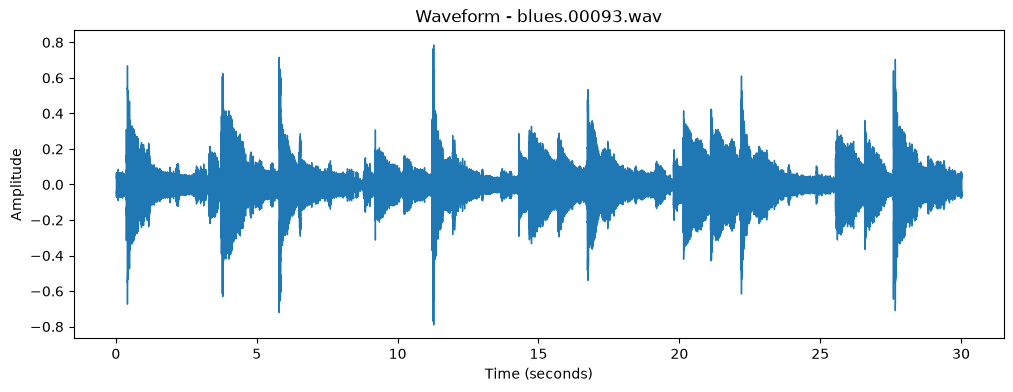

In [10]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(y, sr=sr)

plt.title(f"Waveform - {sample_file}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

## Extracting MFCC Features

MFCCs (Mel-Frequency Cepstral Coefficients) are important audio features used to describe the spectral characteristics of a sound.

I will extract 13 MFCC coefficients from the sample audio file and visualize them before applying the same process to the full dataset.

In [11]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (13, 1293)


### MFCC Visualization

The MFCC matrix shows how the spectral characteristics of the audio change over time.

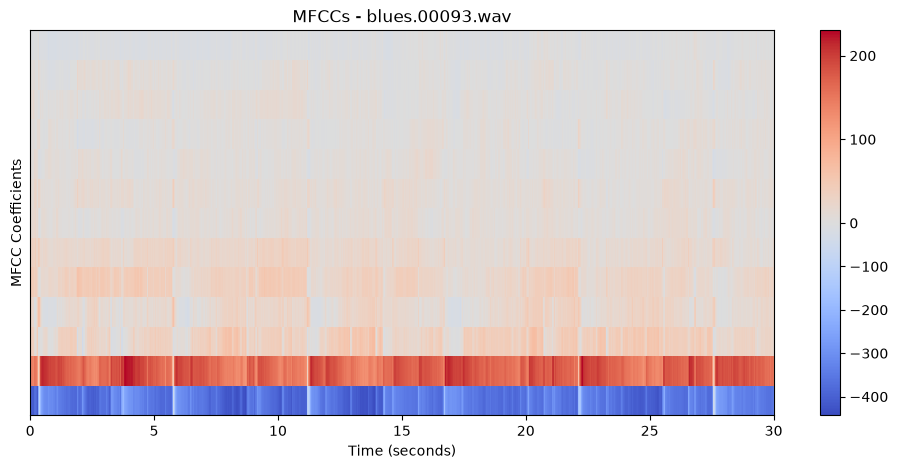

In [12]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title(f"MFCCs - {sample_file}")
plt.ylabel("MFCC Coefficients")
plt.xlabel("Time (seconds)")
plt.show()

In [13]:
mfcc_features = {}

for i in range(13):
    mfcc_features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
    mfcc_features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

mfcc_features

{'mfcc_1_mean': np.float32(-350.35263),
 'mfcc_1_std': np.float32(51.5437),
 'mfcc_2_mean': np.float32(169.53174),
 'mfcc_2_std': np.float32(24.951685),
 'mfcc_3_mean': np.float32(31.77135),
 'mfcc_3_std': np.float32(17.795692),
 'mfcc_4_mean': np.float32(16.71844),
 'mfcc_4_std': np.float32(14.611664),
 'mfcc_5_mean': np.float32(28.658941),
 'mfcc_5_std': np.float32(13.71924),
 'mfcc_6_mean': np.float32(19.246181),
 'mfcc_6_std': np.float32(8.286598),
 'mfcc_7_mean': np.float32(7.845076),
 'mfcc_7_std': np.float32(6.3722224),
 'mfcc_8_mean': np.float32(10.037885),
 'mfcc_8_std': np.float32(6.0529),
 'mfcc_9_mean': np.float32(4.7406454),
 'mfcc_9_std': np.float32(6.3769264),
 'mfcc_10_mean': np.float32(2.9217067),
 'mfcc_10_std': np.float32(6.055874),
 'mfcc_11_mean': np.float32(3.900229),
 'mfcc_11_std': np.float32(6.8240967),
 'mfcc_12_mean': np.float32(1.8129543),
 'mfcc_12_std': np.float32(6.5081186),
 'mfcc_13_mean': np.float32(-5.969145),
 'mfcc_13_std': np.float32(5.956467)}

## Extracting Chroma Features

Chroma features describe the distribution of audio energy across the 12 pitch classes of Western music.

I will extract the 12 chroma features and calculate their mean and standard deviation for the sample audio file.

In [14]:
chroma = librosa.feature.chroma_stft(
    y=y,
    sr=sr
)

print("Chroma shape:", chroma.shape)

Chroma shape: (12, 1293)


### Chroma Feature Summary

The chroma features are calculated for each audio frame. To create a fixed-size representation for each song, I will use the mean and standard deviation of each chroma feature.

In [15]:
chroma_features = {}

for i in range(12):
    chroma_features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
    chroma_features[f"chroma_{i+1}_std"] = np.std(chroma[i])

chroma_features

{'chroma_1_mean': np.float32(0.41528466),
 'chroma_1_std': np.float32(0.25665113),
 'chroma_2_mean': np.float32(0.18875138),
 'chroma_2_std': np.float32(0.12372753),
 'chroma_3_mean': np.float32(0.23855865),
 'chroma_3_std': np.float32(0.27685243),
 'chroma_4_mean': np.float32(0.33468428),
 'chroma_4_std': np.float32(0.31799433),
 'chroma_5_mean': np.float32(0.37628296),
 'chroma_5_std': np.float32(0.35292533),
 'chroma_6_mean': np.float32(0.38567984),
 'chroma_6_std': np.float32(0.29871133),
 'chroma_7_mean': np.float32(0.5219945),
 'chroma_7_std': np.float32(0.31566045),
 'chroma_8_mean': np.float32(0.29904237),
 'chroma_8_std': np.float32(0.19497271),
 'chroma_9_mean': np.float32(0.33445936),
 'chroma_9_std': np.float32(0.32295957),
 'chroma_10_mean': np.float32(0.39798138),
 'chroma_10_std': np.float32(0.30767938),
 'chroma_11_mean': np.float32(0.44052362),
 'chroma_11_std': np.float32(0.27187413),
 'chroma_12_mean': np.float32(0.5990954),
 'chroma_12_std': np.float32(0.36434767)}

## Extracting Spectral Centroid

The spectral centroid represents the center of mass of the frequency spectrum.

It is often used as an indicator of how bright or high-frequency a sound is.

In [16]:
spectral_centroid = librosa.feature.spectral_centroid(
    y=y,
    sr=sr
)

print("Spectral centroid shape:", spectral_centroid.shape)

Spectral centroid shape: (1, 1293)


### Spectral Centroid Summary

The spectral centroid is calculated for each audio frame. I will use its mean and standard deviation to represent the overall spectral brightness and variation of the song.

In [17]:
spectral_centroid_features = {
    "spectral_centroid_mean": np.mean(spectral_centroid),
    "spectral_centroid_std": np.std(spectral_centroid)
}

spectral_centroid_features

{'spectral_centroid_mean': np.float64(570.3499042411772),
 'spectral_centroid_std': np.float64(323.95543161972716)}

## Extracting Spectral Bandwidth

The spectral bandwidth measures how spread out the frequencies are around the spectral centroid.

It provides information about the range of frequencies present in the audio signal.

In [18]:
spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=y,
    sr=sr
)

print("Spectral bandwidth shape:", spectral_bandwidth.shape)

Spectral bandwidth shape: (1, 1293)


### Spectral Bandwidth Summary

The spectral bandwidth is calculated for each audio frame. I will use its mean and standard deviation to represent how widely the frequencies are distributed across the song.

In [19]:
spectral_bandwidth_features = {
    "spectral_bandwidth_mean": np.mean(spectral_bandwidth),
    "spectral_bandwidth_std": np.std(spectral_bandwidth)
}

spectral_bandwidth_features

{'spectral_bandwidth_mean': np.float64(995.5058534728203),
 'spectral_bandwidth_std': np.float64(291.04050844120565)}

## Extracting Spectral Rolloff

The spectral rolloff represents the frequency below which a certain percentage of the total spectral energy is contained.

It can help describe how much of the audio energy is concentrated in lower or higher frequencies.

In [20]:
spectral_rolloff = librosa.feature.spectral_rolloff(
    y=y,
    sr=sr
)

print("Spectral rolloff shape:", spectral_rolloff.shape)

Spectral rolloff shape: (1, 1293)


### Spectral Rolloff Summary

The spectral rolloff is calculated for each audio frame. I will use its mean and standard deviation to represent the overall distribution of spectral energy in the song.

In [21]:
spectral_rolloff_features = {
    "spectral_rolloff_mean": np.mean(spectral_rolloff),
    "spectral_rolloff_std": np.std(spectral_rolloff)
}

spectral_rolloff_features

{'spectral_rolloff_mean': np.float64(929.3001037739269),
 'spectral_rolloff_std': np.float64(707.08712896986)}

## Extracting Zero-Crossing Rate

The zero-crossing rate measures how often the audio signal changes sign.

It can provide information about the characteristics of the sound and the amount of high-frequency content.

In [22]:
zero_crossing_rate = librosa.feature.zero_crossing_rate(y)

print("Zero-crossing rate shape:", zero_crossing_rate.shape)

Zero-crossing rate shape: (1, 1293)


### Zero-Crossing Rate Summary

The zero-crossing rate is calculated for each audio frame. I will use its mean and standard deviation to represent the overall rate of sign changes in the song.

In [23]:
zero_crossing_rate_features = {
    "zero_crossing_rate_mean": np.mean(zero_crossing_rate),
    "zero_crossing_rate_std": np.std(zero_crossing_rate)
}

zero_crossing_rate_features

{'zero_crossing_rate_mean': np.float64(0.02169698315448569),
 'zero_crossing_rate_std': np.float64(0.010838293447427707)}

## Extracting RMS Energy

RMS energy represents the average magnitude of the audio signal.

It can provide information about the energy and loudness characteristics of the song.

In [24]:
rms = librosa.feature.rms(y=y)

print("RMS shape:", rms.shape)

RMS shape: (1, 1293)


### RMS Energy Summary

The RMS energy is calculated for each audio frame. I will use its mean and standard deviation to represent the overall energy and variation of the song.

In [25]:
rms_features = {
    "rms_mean": np.mean(rms),
    "rms_std": np.std(rms)
}

rms_features

{'rms_mean': np.float32(0.06586), 'rms_std': np.float32(0.042473443)}

## Extracting Tempo

Tempo represents the estimated speed of the musical rhythm and is measured in beats per minute (BPM).

I will extract the tempo of the sample audio file as an additional feature.

In [26]:
tempo, _ = librosa.beat.beat_track(
    y=y,
    sr=sr
)

tempo = float(np.asarray(tempo).reshape(-1)[0])

print("Estimated tempo:", tempo, "BPM")

Estimated tempo: 58.72691761363637 BPM


## Creating the Feature Extraction Function

I will combine the feature extraction steps into a single function.

The function will load an audio file and extract MFCC, chroma, spectral, zero-crossing rate, RMS, and tempo features.

In [27]:
def extract_features(file_path):
    y, sr = librosa.load(
        file_path,
        sr=22050,
        mono=True
    )

    features = {}

    # MFCC features
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # Chroma features
    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr
    )

    for i in range(12):
        features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
        features[f"chroma_{i+1}_std"] = np.std(chroma[i])

    # Spectral centroid
    spectral_centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )

    features["spectral_centroid_mean"] = np.mean(spectral_centroid)
    features["spectral_centroid_std"] = np.std(spectral_centroid)

    # Spectral bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr
    )

    features["spectral_bandwidth_mean"] = np.mean(spectral_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spectral_bandwidth)

    # Spectral rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr
    )

    features["spectral_rolloff_mean"] = np.mean(spectral_rolloff)
    features["spectral_rolloff_std"] = np.std(spectral_rolloff)

    # Zero-crossing rate
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y)

    features["zero_crossing_rate_mean"] = np.mean(zero_crossing_rate)
    features["zero_crossing_rate_std"] = np.std(zero_crossing_rate)

    # RMS energy
    rms = librosa.feature.rms(y=y)

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # Tempo
    tempo, _ = librosa.beat.beat_track(
        y=y,
        sr=sr
    )

    features["tempo"] = float(
        np.asarray(tempo).reshape(-1)[0]
    )

    return features

In [28]:
sample_features = extract_features(sample_path)

print("Number of extracted features:", len(sample_features))

Number of extracted features: 61


### Checking the Extracted Feature Names

I will check the extracted feature names to make sure that all expected audio features are included.

In [29]:
print("Feature names:")
print(list(sample_features.keys()))

Feature names:
['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'chroma_1_mean', 'chroma_1_std', 'chroma_2_mean', 'chroma_2_std', 'chroma_3_mean', 'chroma_3_std', 'chroma_4_mean', 'chroma_4_std', 'chroma_5_mean', 'chroma_5_std', 'chroma_6_mean', 'chroma_6_std', 'chroma_7_mean', 'chroma_7_std', 'chroma_8_mean', 'chroma_8_std', 'chroma_9_mean', 'chroma_9_std', 'chroma_10_mean', 'chroma_10_std', 'chroma_11_mean', 'chroma_11_std', 'chroma_12_mean', 'chroma_12_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'zero_crossing_rate_mean', 'zero_crossing_ra

## Extracting Features from the Full Dataset

I will apply the feature extraction function to all audio files across the ten genres.

For each song, I will store the extracted audio features along with the file name and genre.

If an audio file cannot be processed, I will record its file name and error without stopping the extraction process.

In [39]:
all_features = []
failed_files = []

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)

    files = sorted([
        file for file in os.listdir(genre_path)
        if file.lower().endswith(".wav")
    ])

    for file in files:
        file_path = os.path.join(genre_path, file)

        try:
            features = extract_features(file_path)

            features["filename"] = file
            features["genre"] = genre

            all_features.append(features)

        except Exception as e:
            failed_files.append({
                "filename": file,
                "genre": genre,
                "error": str(e)
            })

print("Successfully processed:", len(all_features))
print("Failed files:", len(failed_files))

Successfully processed: 999
Failed files: 1


### Checking Failed Files

One audio file could not be processed because its format was not recognized by the audio loading library.

I will keep a record of the failed file so that the issue is documented rather than silently ignored.

In [40]:
failed_files_df = pd.DataFrame(failed_files)

failed_files_df

,filename,genre,error
0,jazz.00054.wav,jazz,Error opening 'data/genres_original/jazz/jazz....


## Creating the Feature Dataset

I will convert the extracted features into a DataFrame.

Each row represents one song, while the columns contain the extracted audio features, file name, and genre.

In [41]:
features_df = pd.DataFrame(all_features)

print("Feature dataset shape:", features_df.shape)

Feature dataset shape: (999, 63)


## Inspecting the Feature Dataset

I will inspect the first few rows of the extracted feature dataset to make sure the features were stored correctly.

In [42]:
features_df.head()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,zero_crossing_rate_mean,zero_crossing_rate_std,rms_mean,rms_std,tempo,filename,genre
0,-113.598824,50.688946,121.570671,17.200207,-19.162262,15.348761,42.363937,12.289782,-6.362266,12.961207,...,292.975102,3805.723030,949.343413,0.083045,0.027694,0.130184,0.053183,123.046875,blues.00000.wav,blues
1,-207.523834,88.142525,123.985138,23.662489,8.947019,23.923552,35.867149,16.270117,2.909595,16.732485,...,462.498760,3550.713616,1725.778347,0.056040,0.038046,0.095908,0.048711,67.999589,blues.00001.wav,blues
2,-90.757164,57.601101,140.440872,22.557840,-29.084547,20.299370,31.686693,11.998093,-13.976547,12.476432,...,276.216244,3042.410115,885.511646,0.076291,0.031731,0.175473,0.052449,161.499023,blues.00002.wav,blues
3,-199.575134,74.217697,150.086105,21.361393,5.663404,16.034643,26.855278,12.584162,1.770071,16.369904,...,408.107638,2184.879029,1221.915647,0.033309,0.020561,0.141040,0.079672,63.024009,blues.00003.wav,blues
4,-160.354172,72.104813,126.209480,29.210808,-35.581394,18.276550,22.139256,13.919527,-32.473549,18.341904,...,297.285560,3579.957471,1253.928347,0.101461,0.044205,0.091501,0.048013,135.999178,blues.00004.wav,blues


## Checking Missing Values

I will check the extracted feature dataset for missing values before preparing the data for modeling.

In [43]:
features_df.isnull().sum().sum()

np.int64(0)

## Checking Genre Distribution

I will check the number of songs available for each genre after feature extraction.

In [44]:
features_df["genre"].value_counts().sort_index()

genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz          99
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64

## Saving the Extracted Features

I will save the extracted audio features to a CSV file so they can be reused during the modeling stage without extracting the features again.

In [ ]:
features_df.to_csv(
    "data/extracted_features.csv",
    index=False
)

print("Feature dataset saved successfully")

Feature dataset saved successfully.


## Preparing the Data for Modeling

I will separate the audio features from the target genre.

The filename will not be used as a feature because it only identifies the audio file.

In [46]:
X = features_df.drop(columns=["filename", "genre"])
y = features_df["genre"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (999, 61)
Target shape: (999,)


## Encoding the Target Labels

The genre names are categorical labels, so I will convert them into numeric labels that can be used by the classification model.

In [47]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Genre classes:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

Genre classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Encoded labels: [0 1 2 3 4 5 6 7 8 9]


## Multi-Class Classification Setup

The dataset contains ten music genres, so this is a multi-class classification problem.

Each song belongs to one of the ten genre classes.

## Splitting the Dataset

I will split the dataset into training and testing sets.

The training set will be used to train the classification model, while the testing set will be used to evaluate its performance on unseen songs.

Stratified splitting will be used to keep a similar genre distribution in both sets.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (799, 61)
Testing set shape: (200, 61)


## Scaling the Features

The extracted audio features have different value ranges, so I will standardize them before training the classification model.

The scaler will be fitted only on the training data to avoid data leakage.

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape:", X_test_scaled.shape)

Scaled training set shape: (799, 61)
Scaled testing set shape: (200, 61)


## Training a Baseline Model

I will start with Logistic Regression as a baseline model for the multi-class music genre classification task.

This baseline will provide a reference point that can be compared with other classification models later.

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully.


In [55]:
y_pred = logistic_model.predict(X_test_scaled)

print("Number of predictions:", len(y_pred))
print("Predictions:", y_pred[:10])

Number of predictions: 200
Predictions: [1 8 6 5 0 2 3 0 3 5]


## Evaluating the Baseline Model

I will evaluate the baseline model using accuracy to measure the proportion of correctly classified songs in the test set.

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.665


## Classification Report

I will calculate precision, recall, and F1-score for each music genre to get a more detailed view of the model performance.

In [59]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       blues       0.76      0.65      0.70        20
   classical       1.00      0.85      0.92        20
     country       0.62      0.65      0.63        20
       disco       0.38      0.40      0.39        20
      hiphop       0.70      0.70      0.70        20
        jazz       0.72      0.90      0.80        20
       metal       0.85      0.85      0.85        20
         pop       0.70      0.80      0.74        20
      reggae       0.46      0.60      0.52        20
        rock       0.50      0.25      0.33        20

    accuracy                           0.67       200
   macro avg       0.67      0.66      0.66       200
weighted avg       0.67      0.67      0.66       200



## Confusion Matrix

I will use a confusion matrix to examine which music genres are correctly classified and which genres are commonly confused with each other.

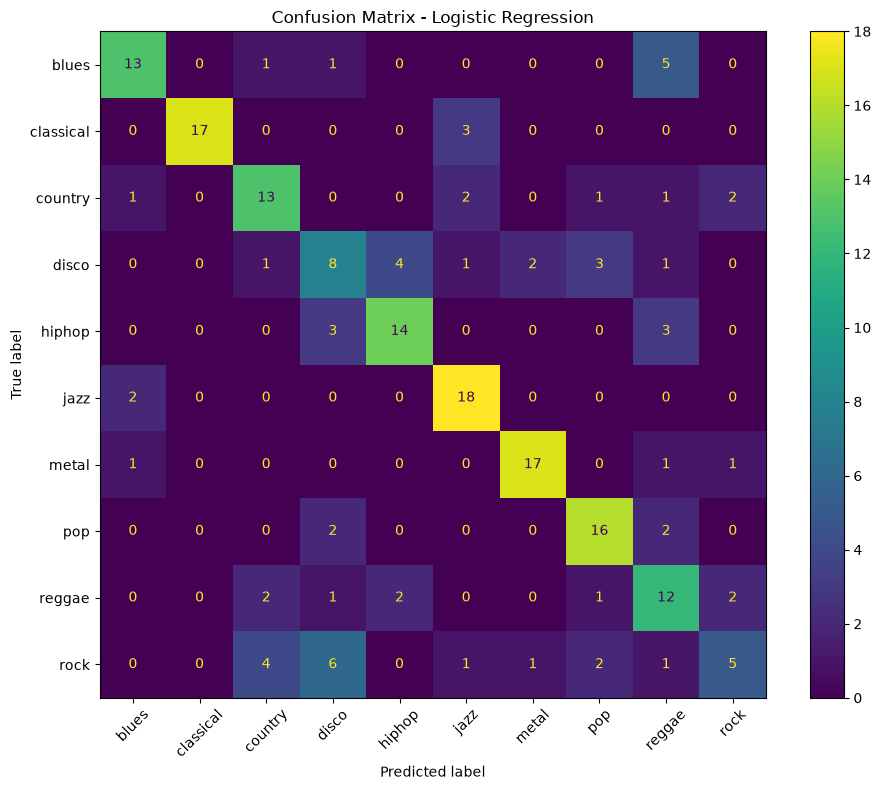

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

## Training a Random Forest Model

I will train a Random Forest classifier using the extracted audio features.

Random Forest can capture non-linear relationships between the audio features and the music genres.

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully.


## Making Predictions with Random Forest

I will use the trained Random Forest model to predict the genres of the songs in the testing set.

In [63]:
y_pred_rf = random_forest_model.predict(X_test)

print("Number of predictions:", len(y_pred_rf))
print("Predictions:", y_pred_rf[:10])

Number of predictions: 200
Predictions: [1 0 6 5 8 2 9 5 3 5]


## Evaluating the Random Forest Model

I will evaluate the Random Forest model using accuracy and compare its performance with the baseline Logistic Regression model.

In [64]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Test Accuracy:", accuracy_rf)

Random Forest Test Accuracy: 0.665


## Random Forest Classification Report

I will calculate precision, recall, and F1-score for each genre to compare the Random Forest performance across the different music genres.

In [65]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       blues       0.64      0.45      0.53        20
   classical       0.90      0.95      0.93        20
     country       0.54      0.70      0.61        20
       disco       0.50      0.55      0.52        20
      hiphop       0.52      0.60      0.56        20
        jazz       0.78      0.90      0.84        20
       metal       0.89      0.80      0.84        20
         pop       0.76      0.80      0.78        20
      reggae       0.56      0.50      0.53        20
        rock       0.57      0.40      0.47        20

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200



## Training a Support Vector Machine

I will train a Support Vector Machine classifier using the standardized audio features.

SVM can work well with high-dimensional feature spaces and may capture class boundaries that are not easily separated by a linear model.

In [ ]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully")

SVM model trained successfully.


## Making Predictions with SVM

I will use the trained SVM model to predict the genres of the songs in the testing set.

In [70]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("Number of predictions:", len(y_pred_svm))
print("Predictions:", y_pred_svm[:10])

Number of predictions: 200
Predictions: [1 0 6 5 8 2 9 5 3 5]


In [71]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Test Accuracy:", accuracy_svm)

SVM Test Accuracy: 0.685


In [72]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       blues       0.74      0.70      0.72        20
   classical       0.95      0.90      0.92        20
     country       0.62      0.65      0.63        20
       disco       0.45      0.45      0.45        20
      hiphop       0.52      0.60      0.56        20
        jazz       0.79      0.95      0.86        20
       metal       0.79      0.75      0.77        20
         pop       0.70      0.80      0.74        20
      reggae       0.65      0.55      0.59        20
        rock       0.67      0.50      0.57        20

    accuracy                           0.69       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.69      0.68       200



## SVM Confusion Matrix

I will use a confusion matrix to examine the classification errors made by the SVM model and identify the genres that are most commonly confused with each other.

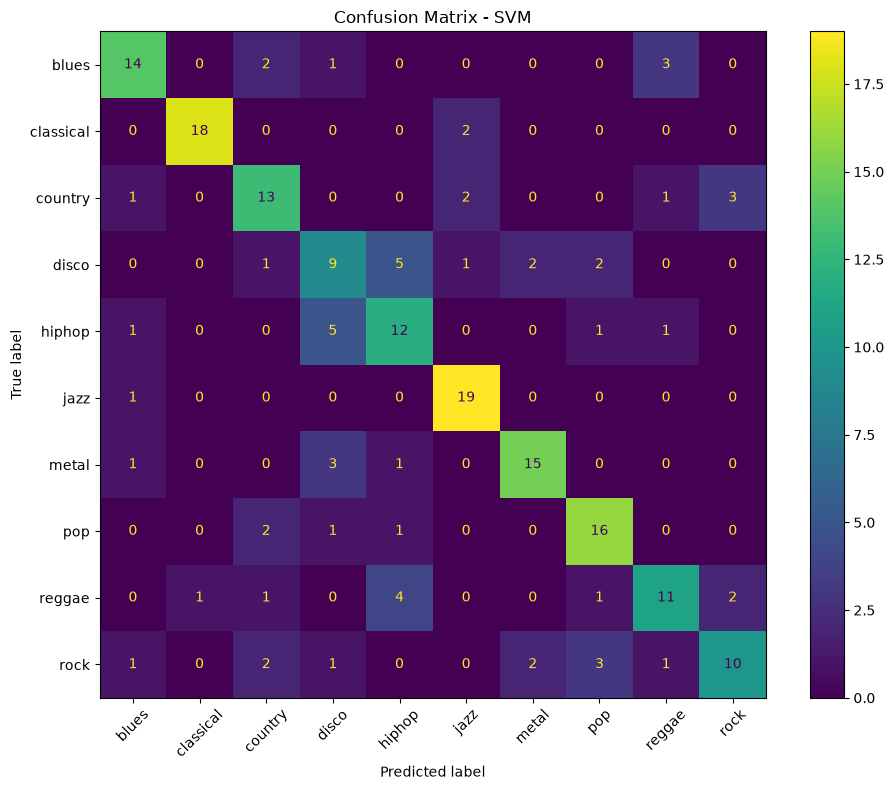

In [73]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - SVM")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning for SVM

I will tune the SVM hyperparameters using cross-validation on the training data.

The test set will not be used during tuning so that it remains unseen for the final evaluation.

In [ ]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001]
}

grid_search = GridSearchCV(
    estimator=SVC(
        kernel="rbf",
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)

Best parameters: {'C': 100, 'gamma': 'scale'}
Best cross-validation F1-score: 0.7382989155450799


In [76]:
best_svm_model = SVC(
    kernel="rbf",
    C=100,
    gamma="scale",
    random_state=42
)

best_svm_model.fit(X_train_scaled, y_train)

y_pred_best_svm = best_svm_model.predict(X_test_scaled)

print("Tuned SVM model trained successfully.")
print("Number of predictions:", len(y_pred_best_svm))

Tuned SVM model trained successfully.
Number of predictions: 200


In [77]:
accuracy_tuned = accuracy_score(y_test, y_pred_best_svm)
precision_tuned = precision_score(
    y_test,
    y_pred_best_svm,
    average="macro"
)
recall_tuned = recall_score(
    y_test,
    y_pred_best_svm,
    average="macro"
)
f1_tuned = f1_score(
    y_test,
    y_pred_best_svm,
    average="macro"
)

print("Tuned SVM Results")
print("-----------------")
print("Accuracy:", accuracy_tuned)
print("Macro Precision:", precision_tuned)
print("Macro Recall:", recall_tuned)
print("Macro F1-Score:", f1_tuned)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best_svm,
        target_names=label_encoder.classes_
    )
)

Tuned SVM Results
-----------------
Accuracy: 0.705
Macro Precision: 0.7056308842516272
Macro Recall: 0.705
Macro F1-Score: 0.7014409968461165

Classification Report:
              precision    recall  f1-score   support

       blues       0.79      0.75      0.77        20
   classical       0.90      0.90      0.90        20
     country       0.56      0.70      0.62        20
       disco       0.65      0.55      0.59        20
      hiphop       0.64      0.70      0.67        20
        jazz       0.79      0.95      0.86        20
       metal       0.89      0.80      0.84        20
         pop       0.70      0.70      0.70        20
      reggae       0.57      0.60      0.59        20
        rock       0.57      0.40      0.47        20

    accuracy                           0.70       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.71      0.70      0.70       200



<Figure size 1000x800 with 0 Axes>

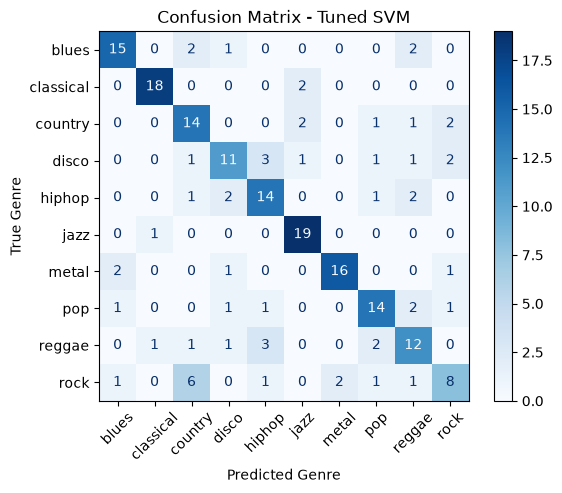

In [79]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_best_svm
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Tuned SVM")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.show()

## Model Comparison

Several classification models were tested using the same training and test sets.

The SVM with RBF kernel achieved the highest test performance among the tested models. Hyperparameter tuning further improved its test accuracy from 68.5% to 70.5% and its macro F1-score from 68.26% to 70.14%.

Therefore, the tuned SVM was selected as the final model for the music genre classification system.

In [81]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Tuned SVM"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_svm,
        accuracy_tuned
    ],
    "Macro Precision": [
        precision_score(y_test, y_pred, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro"),
        precision_score(y_test, y_pred_svm, average="macro"),
        precision_tuned
    ],
    "Macro Recall": [
        recall_score(y_test, y_pred, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro"),
        recall_score(y_test, y_pred_svm, average="macro"),
        recall_tuned
    ],
    "Macro F1-Score": [
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_svm, average="macro"),
        f1_tuned
    ]
})

model_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
0,Logistic Regression,0.665,0.669190,0.665,0.659527
1,Random Forest,0.665,0.666821,0.665,0.660359
2,SVM,0.685,0.686552,0.685,0.682639
3,Tuned SVM,0.705,0.705631,0.705,0.701441


## Saving the Final Model

The tuned SVM was selected as the final model based on its performance on the test set.

I will save the model together with the scaler, label encoder, and feature names so they can be reused later for predictions on new audio files.

In [83]:
model_artifact = {
    "model": best_svm_model,
    "scaler": scaler,
    "label_encoder": label_encoder,
    "feature_names": X.columns.tolist()
}

joblib.dump(
    model_artifact,
    "artifacts/music_genre_model.pkl"
)

print("Final model artifact saved successfully")

Final model artifact saved successfully


## Testing the Saved Model

I will reload the saved model artifact and use it to make predictions on the test data.

This confirms that the saved components can be loaded and used correctly for future predictions.

In [84]:
loaded_artifact = joblib.load(
    "artifacts/music_genre_model.pkl"
)

loaded_model = loaded_artifact["model"]
loaded_scaler = loaded_artifact["scaler"]
loaded_label_encoder = loaded_artifact["label_encoder"]
loaded_feature_names = loaded_artifact["feature_names"]

X_test_loaded = X_test[loaded_feature_names]

X_test_loaded_scaled = loaded_scaler.transform(
    X_test_loaded
)

loaded_predictions = loaded_model.predict(
    X_test_loaded_scaled
)

print("Saved model loaded successfully.")
print("Number of predictions:", len(loaded_predictions))
print("First 10 predictions:", loaded_predictions[:10])

Saved model loaded successfully.
Number of predictions: 200
First 10 predictions: [1 0 6 5 0 2 9 5 3 5]


In [85]:
decoded_predictions = loaded_label_encoder.inverse_transform(
    loaded_predictions[:10]
)

print("First 10 predicted genres:")
print(decoded_predictions)

First 10 predicted genres:
['classical' 'blues' 'metal' 'jazz' 'blues' 'country' 'rock' 'jazz'
 'disco' 'jazz']


## Final Conclusion

The GTZAN dataset was used to build a multi-class music genre classification system.

Audio features were extracted from the songs using Librosa, including MFCCs, chroma, spectral centroid, spectral bandwidth, spectral rolloff, zero-crossing rate, RMS energy, and tempo.

Several machine learning models were trained and evaluated using the same test set. The tuned SVM achieved the highest test performance among the tested models, with 70.5% accuracy and a macro F1-score of 70.14%.

The final SVM model, scaler, label encoder, and feature names were saved as an artifact for future use.